In [31]:
import os

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = '/content/drive/MyDrive/TFM_NoeliaGarciaGarcia/Pipeline'
else:
    BASE_PATH = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Lectura de parámetros desde config.xlsx
config = pd.read_excel(os.path.join(BASE_PATH, "NOTEBOOKS", "config.xlsx"), sheet_name="config", index_col="parameter")["value"]
min_k_clusters = int(config["min_k_clusters"])
max_k_clusters = int(config["max_k_clusters"])
k_final = int(config["k_final"])

print(f"Entorno: {'Colab' if IN_COLAB else 'Local'}")
print(f"BASE_PATH: {BASE_PATH}")

print(f"Rango de clusters: {min_k_clusters} a {max_k_clusters}")
print(f"k_final: {k_final}")

Entorno: Local
BASE_PATH: g:\Mi unidad\TFM_NoeliaGarciaGarcia\Pipeline
Rango de clusters: 2 a 8
k_final: 2


Primero se aplican técnicas de aprendizaje no supervisado para definir el clasificador y dividir las ventanas.

Después se hará todo el proceso para construir un modelo que prediga esa clasificación en función de las variables.

Clustering se define como agrupar puntos usando una distancia, de forma que los puntos dentro de un mismo grupo sean parecidos y los puntos de grupos distintos sean diferentes.

Número de clústers = k

Si k=2 quiere decir que se van a clasificar los datos en dos grupos, por ejemplo grupo0 = "poco oleaje" y grupo1= "mucho oleaje".

Un centroide es el centro de un grupo.

* Ventana A: Oleaje 0.4, Mod_orbital 0.05
* Ventana B: Oleaje 0.6, Mod_orbital 0.07
* Ventana C: Oleaje 0.5, Mod_orbital 0.06

El centroide sería algo parecido a:

* Oleaje medio = 0.5
* Mod_orbital medio = 0.06

Es decir, el centroide representa el “promedio” del grupo.

Por eso K-Means funciona bien con variables numéricas continuas, porque está basado en distancias euclídeas y centroides.

# CARGA DE DATOS

In [32]:
base_path = os.path.join(BASE_PATH, "DATA", "PROCESSED")

df_oleaje = pd.read_csv(os.path.join(base_path, "df_wave.csv"))
df_features = pd.read_csv(os.path.join(base_path, "df_features.csv"))

df = pd.merge(
    df_oleaje,
    df_features,
    on="window_id",
    how="inner"
)

df_oleaje.head()

,window_id,hour,day,flux_O2,accumulated_flux_O2,optimal_shift_samples,optimal_shift_sec,optimal_shift_day,mean_vz,mean_O2,...,flux_smooth,flag_outlier_global,flag_outlier_window,flag_flux_positivo,flag_vz_baja,Oleaje,Mod_orbital,STD_orbital,hour_int,Oleaje_SIMAR
0,0,13.12,0.546875,-9.869224,-0.102804,-8.0,-1.000,-0.000012,-0.000940,219.341074,...,-6.351335,False,False,False,False,9.664,0.015203,0.009969,13,1.87
1,1,13.37,0.557292,-12.440802,-0.129592,-7.0,-0.875,-0.000010,-0.001864,220.214211,...,-6.745481,False,False,False,False,9.876,0.015946,0.010475,13,1.87
2,2,13.62,0.567709,-6.206313,-0.064649,-8.0,-1.000,-0.000012,-0.001838,220.537457,...,-6.619435,False,False,False,False,9.004,0.013689,0.008438,13,1.87
3,3,13.87,0.578125,-3.094532,-0.032235,15.0,1.875,0.000022,-0.001537,220.398051,...,-6.799723,False,False,False,False,8.556,0.012808,0.008059,13,1.87
4,4,14.12,0.588542,-10.561338,-0.110014,-7.0,-0.875,-0.000010,-0.001444,220.429227,...,-6.911006,False,False,False,False,9.500,0.013456,0.007926,14,1.86


# IMPLEMENTACIÓN K-MEANS

In [33]:
# Se eligen las variables que afectan a la clasificación
features = [
    "Oleaje",
    "Mod_orbital",
    "STD_orbital",
    "pres__mean",
    "pres__standard_deviation",
    "pres__median"
]

# Prueba con SIMAR
# features = [
#     "Oleaje_SIMAR",
#     "pres__mean",
#     "pres__standard_deviation",
#     "pres__median"
# ]

In [34]:
# Se prepara la matriz X
X = df[features].copy()

imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_imputed = imputer.fit_transform(X)
X_scaled = scaler.fit_transform(X_imputed)

# EVALUACIÓN DE NÚMERO DE CLÚSTERS

In [35]:
# Se evalúa el número de clústers
k_values = range(min_k_clusters, max_k_clusters + 1)

inertias = []
silhouettes = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = kmeans.fit_predict(X_scaled)

    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

df_k_eval = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertias,
    "silhouette": silhouettes
})

display(df_k_eval)

,k,inertia,silhouette
0,2,2152.374106,0.395311
1,3,1492.592996,0.389897
2,4,1120.435527,0.381077
3,5,879.555746,0.385002
4,6,735.428295,0.384184
5,7,656.779782,0.394414
6,8,579.382102,0.393248


Para seleccionar el número de grupos en KMeans se evaluaron dos criterios: el método del codo y el coeficiente silhouette.

En primer lugar, el método del codo analiza la inercia del modelo para distintos valores de k. La inercia representa la suma de las distancias de cada punto al centroide de su cluster, por lo que valores más bajos indican grupos más compactos. Como es esperable, la inercia disminuye al aumentar el número de clusters, ya que el modelo dispone de más centroides para ajustar los datos. En la gráfica se observa una reducción importante de la inercia entre k = 2 y k = 4. A partir de k = 4, la disminución continúa, pero de forma más suave. Esto sugiere que alrededor de k = 4 aparece un posible “codo”, es decir, un punto a partir del cual añadir más clusters aporta una mejora menor en la compactación de los grupos.

En segundo lugar, se calculó el silhouette score, que evalúa simultáneamente la cohesión interna de los clusters y la separación entre clusters. Este índice toma valores más altos cuando los puntos están bien asignados a su propio grupo y suficientemente separados de los demás.

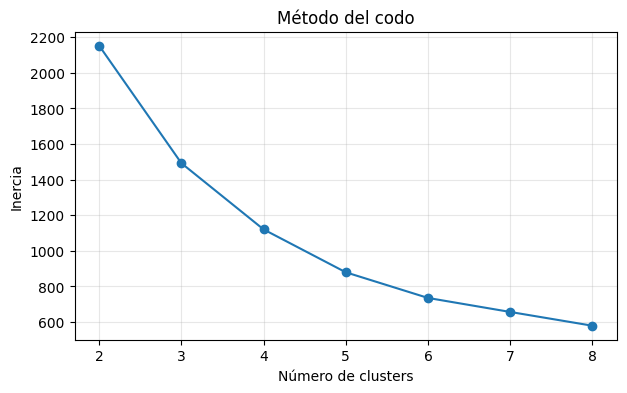

In [36]:
plt.figure(figsize=(7, 4))
plt.plot(df_k_eval["k"], df_k_eval["inertia"], marker="o")
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.title("Método del codo")
plt.grid(True, alpha=0.3)
plt.show()

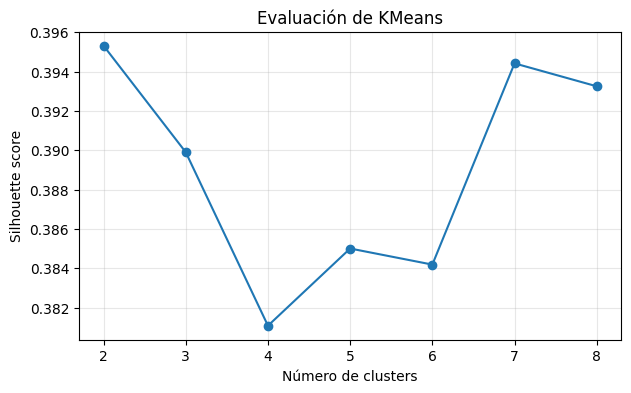

In [37]:
plt.figure(figsize=(7, 4))
plt.plot(df_k_eval["k"], df_k_eval["silhouette"], marker="o")
plt.xlabel("Número de clusters")
plt.ylabel("Silhouette score")
plt.title("Evaluación de KMeans")
plt.grid(True, alpha=0.3)
plt.show()

# APLICACIÓN FINAL DE K-MEANS

In [38]:
# Aplicar k-means final (k_final viene de config.xlsx)
kmeans = KMeans(
    n_clusters=k_final,
    random_state=42,
    n_init=20
)

df["cluster_kmeans"] = kmeans.fit_predict(X_scaled)

In [39]:
orden_clusters = (
    df
    .groupby("cluster_kmeans")["Oleaje"]
    .mean()
    .sort_values()
    .index
    .tolist()
)

mapa_clusters = {
    cluster_original: nuevo_id
    for nuevo_id, cluster_original in enumerate(orden_clusters)
}

df["oleaje_clase"] = df["cluster_kmeans"].map(mapa_clusters)

In [40]:
if k_final == 2:
    nombres_clase = {
        0: "poco_oleaje",
        1: "mucho_oleaje"
    }

else:
    nombres_clase = {
        i: f"clase_{i}"
        for i in range(k_final)
    }

df["oleaje_clase_nombre"] = df["oleaje_clase"].map(nombres_clase)

In [41]:
resumen_clusters = (
    df
    .groupby(["oleaje_clase", "oleaje_clase_nombre"])[features]
    .agg(["count", "mean", "std", "min", "median", "max"])
)

display(resumen_clusters)

Oleaje                                       \
                                  count       mean       std     min  median   
oleaje_clase oleaje_clase_nombre                                               
0            poco_oleaje            284  12.804394  4.060008   8.332  10.230   
1            mucho_oleaje           266  28.381850  5.157088  19.252  27.554   

                                         Mod_orbital                      \
                                     max       count      mean       std   
oleaje_clase oleaje_clase_nombre                                           
0            poco_oleaje          20.896         306  0.021188  0.008440   
1            mucho_oleaje         45.560         354  0.053042  0.010262   

                                            ... pres__standard_deviation  \
                                       min  ...                      std   
oleaje_clase oleaje_clase_nombre            ...                            
0            poco_oleaje          0.011272  ...                 1.030956   
1            mucho_oleaje         0.032143  ...                 1.287506   

                                                                pres__median  \
                                       min    median        max        count   
oleaje_clase oleaje_clase_nombre                                               
0            poco_oleaje          2.285562  4.467242   6.615240          306   
1            mucho_oleaje         5.432638  7.428212  12.124611          354   

                                                                           \
                                         mean        std     min   median   
oleaje_clase oleaje_clase_nombre                                            
0            poco_oleaje          1536.751144  78.980019  1402.3  1530.15   
1            mucho_oleaje         1539.940960  58.697229  1420.6  1544.95   

                                          
                                     max  
oleaje_clase oleaje_clase_nombre          
0            poco_oleaje          1672.8  
1            mucho_oleaje         1644.2  

[2 rows x 36 columns]

# COMPROBACIONES

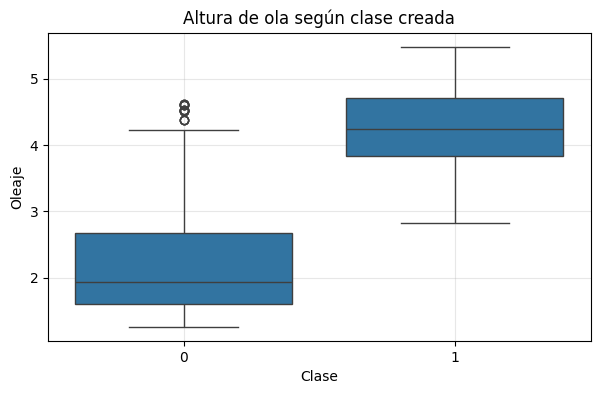

In [42]:
plt.figure(figsize=(7, 4))
sns.boxplot(
    data=df,
    x="oleaje_clase",
    y="Oleaje_SIMAR"
)
plt.title("Altura de ola según clase creada")
plt.xlabel("Clase")
plt.ylabel("Oleaje")
plt.grid(True, alpha=0.3)
plt.show()

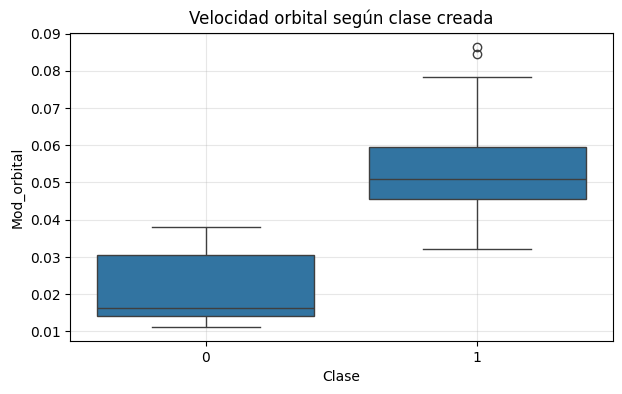

In [43]:
plt.figure(figsize=(7, 4))
sns.boxplot(
    data=df,
    x="oleaje_clase",
    y="Mod_orbital"
)
plt.title("Velocidad orbital según clase creada")
plt.xlabel("Clase")
plt.ylabel("Mod_orbital")
plt.grid(True, alpha=0.3)
plt.show()

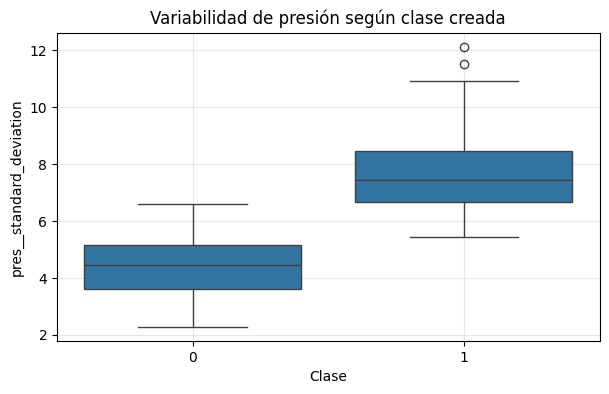

In [44]:
plt.figure(figsize=(7, 4))
sns.boxplot(
    data=df,
    x="oleaje_clase",
    y="pres__standard_deviation"
)
plt.title("Variabilidad de presión según clase creada")
plt.xlabel("Clase")
plt.ylabel("pres__standard_deviation")
plt.grid(True, alpha=0.3)
plt.show()

# CREACIÓN DE FICHEROS CON LOS DATOS CLASIFICADOS

In [45]:
output_path = os.path.join(BASE_PATH, "DATA", "PROCESSED", "df_classified.csv")
df.to_csv(output_path, index=False)
print(f"Datos guardados exitosamente en: {output_path}")

Datos guardados exitosamente en: g:\Mi unidad\TFM_NoeliaGarciaGarcia\Pipeline\DATA\PROCESSED\df_classified.csv
